# 📊 Examen Final: Dataset de Kaggle + Análisis Financiero en Colab
Este notebook contiene las instrucciones para que desarrollar el examen final.

## ⭐ PASO 1 — Buscar un dataset en Kaggle
1. Entra a https://www.kaggle.com/datasets
2. Busca un dataset financiero (acciones, criptomonedas, oro, petróleo, etc.)
3. Descárgalo a tu computador (formato CSV).

## ⭐ PASO 2 — Subir el dataset a Colab

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving TSLA.csv to TSLA (1).csv


In [ ]:
import pandas as pd

# TODO: cambia el nombre del archivo al que subiste
df = pd.read_csv('TSLA.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


## ⭐ PASO 3 — Limpieza y preparación del dataset
- Revisa tipos de datos
- Convierte fechas
- Ordena por fecha
- Maneja valores nulos

In [ ]:
# TODO: escribir aquí tu proceso de limpieza

df.info()

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.sort_values(by='Date').reset_index(drop=True)



df = df.interpolate()
df = df.dropna(subset=['Date', 'Close'])
df.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2956 non-null   object 
 1   Open       2956 non-null   float64
 2   High       2956 non-null   float64
 3   Low        2956 non-null   float64
 4   Close      2956 non-null   float64
 5   Adj Close  2956 non-null   float64
 6   Volume     2956 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 161.8+ KB


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


## ⭐ PASO 4 — Análisis financiero básico
Calcula:
- Rendimiento diario
- Rendimiento promedio
- Volatilidad
- Máx y mín históricos

In [ ]:
from numpy import void
# TODO: calcular métricas financieras

df['Return'] = df['Close'].pct_change()

daily = df['Return'].mean()
print("Rendimiento promedio diario:", daily)


volatility_daily = df['Return'].std()
print("Volatilidad diaria:", volatility_daily)

volatility_annual = df['Return'].std() * (252 ** 0.5)
print("Volatilidad anual:", volatility_annual)


max = df['Close'].max()
print("Máximo:", max)
min = df['Close'].min()
print("Mínimo:", min)

max_date = df.loc[df['Close'].idxmax(), 'Date']
min_date = df.loc[df['Close'].idxmin(), 'Date']

print("Fecha del máximo:", max_date)
print("Fecha del mínimo:", min_date)





Rendimiento promedio diario: 0.002443765390564548
Volatilidad diaria: 0.03559990339031454
Volatilidad anual: 0.5651309464121848
Máximo: 1229.910034
Mínimo: 3.16
Fecha del máximo: 2021-11-04 00:00:00
Fecha del mínimo: 2010-07-07 00:00:00


## ⭐ PASO 5 — Gráficos obligatorios
- Serie de precios
- Rendimientos
- Volumen (si aplica)

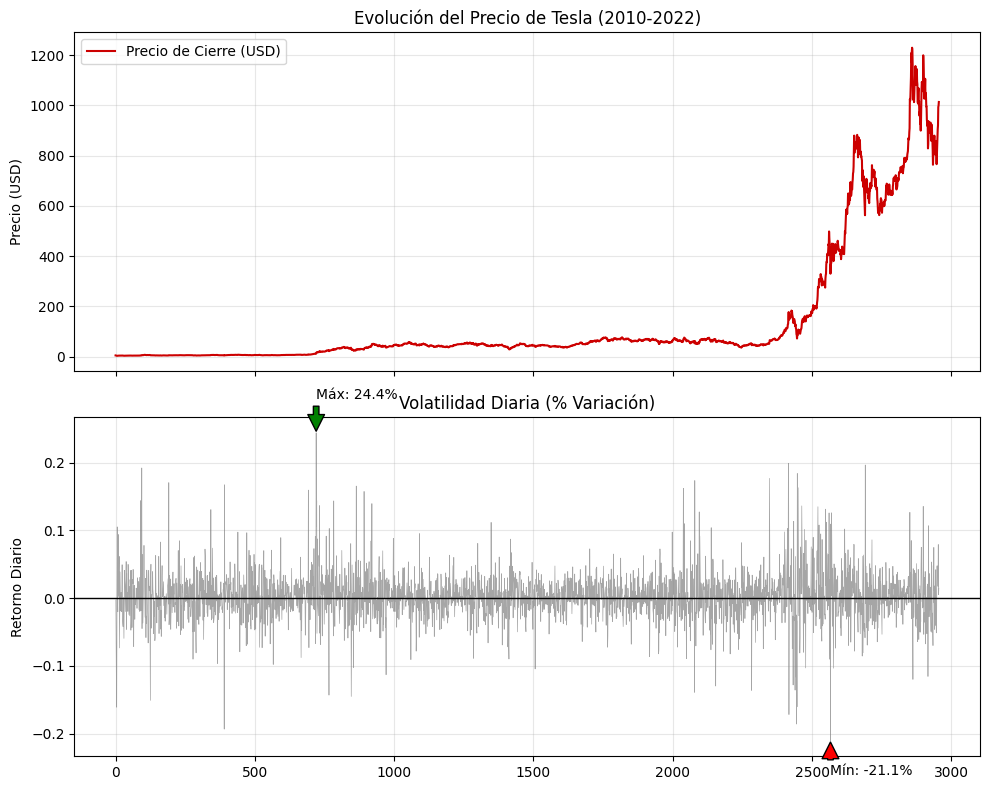

In [ ]:
import matplotlib.pyplot as plt

# TODO: generar gráficos

# Configuración del gráfico
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico 1: Precio de Cierre (Tendencia)
ax1.plot(df.index, df['Close'], color='#cc0000', label='Precio de Cierre (USD)')
ax1.set_title('Evolución del Precio de Tesla (2010-2022)', fontsize=12)
ax1.set_ylabel('Precio (USD)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico 2: Retornos Diarios (Volatilidad)
ax2.plot(df.index, df['Return'], color='gray', alpha=0.7, linewidth=0.5, label='Retorno Diario')
ax2.set_title('Volatilidad Diaria (% Variación)', fontsize=12)
ax2.set_ylabel('Retorno Diario')
ax2.axhline(0, color='black', linewidth=1)
ax2.grid(True, alpha=0.3)


# Identificar eventos extremos en el gráfico
max_ret = df['Return'].max()
min_ret = df['Return'].min()
max_date = df['Return'].idxmax()
min_date = df['Return'].idxmin()

# Anotaciones
ax2.annotate(f'Máx: {max_ret:.1%}', xy=(max_date, max_ret), xytext=(max_date, max_ret+0.05),
             arrowprops=dict(facecolor='green', shrink=0.05))
ax2.annotate(f'Mín: {min_ret:.1%}', xy=(min_date, min_ret), xytext=(min_date, min_ret-0.05),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.tight_layout()
plt.show()


## ⭐ PASO 6 — Preguntas de análisis
1. ¿El activo es volátil? ¿Por qué?
2. ¿Tiene tendencia clara?
3. ¿Hay eventos con movimientos fuertes?
4. ¿Es buena inversión a corto/largo plazo?
5. ¿Limitaciones del dataset?

Escribe tus respuestas abajo.

1. ¿EL ACTIVO ES VOLATIL?
El activo es extremadamente volátil, con una volatilidad anual del 56.5%. Esta volatilidad tan elevada se debe a que Tesla es una acción de crecimiento muy sensible a las expectativas futuras, reaccionando de manera abrupta a noticias, reportes de producción, cambios regulatorios y declaraciones de su CEO, factores que provocan variaciones amplias en su precio frente a los movimientos más estables de empresas tradicionales.

2. ¿TIENE TENDENCIA CLARA? El activo presenta una tendencia alcista clara a largo plazo, evidenciada por un crecimiento exponencial entre finales de 2019 y 2021, donde el precio pasó de aproximadamente 3 USD a más de 1,200 USD. Aunque el tramo 2010–2019 aparenta estabilidad por efectos de escala, el comportamiento general muestra largos periodos de estancamiento seguidos por fases de fuerte euforia, lo que confirma una trayectoria positiva sostenida y notoriamente vertical en el periodo analizado.

3. ¿HAY EVENTOS CON MOVIMIENTOS FUERTES? El activo registra movimientos especialmente fuertes, con días en los que el precio varió entre 10% y 15% en una sola sesión, reflejando una alta sensibilidad a eventos puntuales. El máximo histórico de noviembre de 2021 coincide con anuncios como el acuerdo con Hertz, que impulsó abruptamente el precio, y la volatilidad diaria del 3.5% evidencia que fluctuaciones significativas son normales en Tesla, a diferencia de acciones más estables como Coca-Cola, donde estos movimientos serían excepcionales.

4. ¿ES BUENA INVERSIÓN A CORTO/LARGO PLAZO? A corto plazo, Tesla puede ser lucrativa para traders experimentados debido a su alta volatilidad, aunque implica un riesgo elevado y no es adecuada para quienes buscan proteger capital o disponer del dinero en el corto plazo. A largo plazo ha mostrado rendimientos sobresalientes, con un retorno promedio diario positivo del 0.24%, pero requiere una alta tolerancia al riesgo, ya que la acción ha experimentado caídas de hasta 50% o más, lo que demanda disciplina y evitar decisiones impulsivas durante sus frecuentes retrocesos.

5. ¿LIMITACIONES DEL DATASET? El dataset presenta limitaciones importantes: finaliza a inicios de 2022, por lo que no incluye la caída de más del 60% registrada durante ese año ni la posterior recuperación, lo que genera un sesgo optimista en el análisis. Además, los precios no están ajustados al split 3:1 realizado por Tesla en agosto de 2022. Un split (o “división de acciones”) es un proceso en el que una empresa multiplica la cantidad de acciones en circulación y reduce proporcionalmente el precio de cada acción, sin cambiar el valor total de la compañía; por ejemplo, en un split 3:1, cada acción se divide en tres y su precio se reduce a un tercio. Por esta razón, precios como 1,229 USD del dataset no coinciden con los precios actuales, que están entre 200 y 400 USD tras aplicar el split. El archivo parece estar ajustado al split 5:1 de 2020, pero no al de 2022, lo que genera inconsistencias cuando se comparan estos datos con información reciente del mercado

## ⭐ PASO 7 — Conclusiones
Redacta mínimo 5 conclusiones basadas en tu análisis.

CONCLUSIONES:



*   ETesla presenta una volatilidad extraordinariamente alta, lo que la convierte en un activo riesgoso pero atractivo para estrategias de trading dinámicas. Su comportamiento supera ampliamente la volatilidad típica del mercado, evidenciando sensibilidad extrema a noticias y expectativas.

* El dataset analizado tiene limitaciones relevantes, especialmente por no incluir información posterior a 2022 y por no ajustar correctamente los precios al último split. Estas omisiones pueden sesgar las conclusiones hacia un rendimiento más optimista del que realmente ocurrió

* Los indicadores de rendimiento y riesgo coinciden en que Tesla es una acción extrema, tanto por su potencial de crecimiento como por su susceptibilidad a correcciones violentas. Esto la convierte en una opción adecuada solo para inversionistas con perfil arriesgado o estrategias activas.



